<a href="https://colab.research.google.com/github/PavloBachysh/pattern-recognition-practice/blob/main/notebooks/PR03_Bachysh_Pavlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практична робота 3
## Перша модель і базове оцінювання якості
**Дисципліна:** Розпізнавання образів і машинне навчання
**Студент:** Бачиш Павло
**Група:** ІН-42\2
**Дата виконання:** 01.10.2026
### Мета роботи
Побудувати першу завершену модель машинного навчання,
отримати прогнози та навчитися оцінювати їхню якість
за допомогою основних метрик класифікації.


## 1. Підключення бібліотек


In [97]:
from pathlib import Path
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
 accuracy_score,
 precision_score,
 recall_score,
 f1_score,
 ConfusionMatrixDisplay
)
from IPython.display import display

In [98]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = Path(
 "/content/drive/MyDrive/pattern-recognition-practice"
)
DATA_PATH = (
 PROJECT_DIR
 / "data"
 / "processed"
 / "iris_cleaned.csv"
)
MODELS_DIR = PROJECT_DIR / "models"
REPORTS_DIR = PROJECT_DIR / "reports"
MODEL_PATH = MODELS_DIR / "iris_decision_tree.joblib"
METRICS_PATH = REPORTS_DIR / "model_metrics.csv"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
6
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
print("Файл даних:", DATA_PATH)
print("Файл моделі:", MODEL_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Файл даних: /content/drive/MyDrive/pattern-recognition-practice/data/processed/iris_cleaned.csv
Файл моделі: /content/drive/MyDrive/pattern-recognition-practice/models/iris_decision_tree.joblib


## 2. Завантаження підготовленого набору даних

In [99]:
if not DATA_PATH.exists():
 raise FileNotFoundError(
 "Файл iris_cleaned.csv не знайдено. "
 "Перевірте виконання практичної роботи 2."
 )
data = pd.read_csv(DATA_PATH)
display(data.head())


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species,measurement_device
0,5.1,3.5,1.4,0.2,setosa,device_c
1,5.8,3.0,1.4,0.2,setosa,device_b
2,4.7,3.2,1.3,0.2,setosa,device_c
3,5.1,3.1,1.5,0.2,setosa,device_b
4,5.0,3.6,1.4,0.2,setosa,device_a


In [100]:
print("Розмір таблиці:", data.shape)
print("\nТипи даних:")
print(data.dtypes)
print(
 "\nКількість пропусків:",
 data.isna().sum().sum()
)


Розмір таблиці: (148, 6)

Типи даних:
sepal_length_cm       float64
sepal_width_cm        float64
petal_length_cm       float64
petal_width_cm        float64
species                object
measurement_device     object
dtype: object

Кількість пропусків: 0


1. Скільки об’єктів містить очищений набір? - 148
2. Скільки ознак доступно? - 5
3. Чи залишилися пропущені значення? - ні
4. Який стовпець є цільовою змінною? - передостанній стовпець (species)

In [101]:
X = data.drop(columns=["species"])
y = data["species"]

In [102]:
categorical_columns = X.select_dtypes(
 include=["object", "string", "category"]
).columns.tolist()
print(
 "Категоріальні ознаки:",
 categorical_columns
)


Категоріальні ознаки: ['measurement_device']


In [103]:
X = pd.get_dummies(
 X,
 columns=categorical_columns,
 dtype=int
)
display(X.head())

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,measurement_device_device_a,measurement_device_device_b,measurement_device_device_c
0,5.1,3.5,1.4,0.2,0,0,1
1,5.8,3.0,1.4,0.2,0,1,0
2,4.7,3.2,1.3,0.2,0,0,1
3,5.1,3.1,1.5,0.2,0,1,0
4,5.0,3.6,1.4,0.2,1,0,0


In [104]:
print("Розмір X:", X.shape)
print("Розмір y:", y.shape)

Розмір X: (148, 7)
Розмір y: (148,)


In [105]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
)

In [106]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (118, 7)
X_test: (30, 7)
y_train: (118,)
y_test: (30,)


In [107]:
split_distribution = pd.DataFrame(
 {
 "train_percent": (
 y_train
 .value_counts(normalize=True)
 .sort_index()
 .mul(100)
 .round(2)
 ),
 "test_percent": (
 y_test
 .value_counts(normalize=True)
 .sort_index()
 .mul(100)
 .round(2)
 )
 }
)
display(split_distribution)

,train_percent,test_percent
species,,
setosa,33.90,33.33
versicolor,33.05,33.33
virginica,33.05,33.33


1. Чому тестова вибірка не використовується для навчання? - Бо тестова вибірка використовується для фінальної перевірки моделі. Якщо використати її і для навчання, то ми не зможемо оцінити якість моделі, оскільки в нас не буде "нової" для моделі вибірки, правильні результати якої відомі нам наперед.
2. Для чого встановлено random_state=42? - Можна встановити будь-яке значення. Це початкове значення для генератора випадкових чисел. КОнтролюючи його ми можемо в точності відтворити експеримент і зберегти одні й ті самі випадкові значення (випадковий розподіл).
3. Для чого використовується stratify=y? - Щоб стратифікувати розподіл (в результаті розподілу будуть збалансовані вибірки)
4. Чи близькі частки класів у train і test? - Так

## 3. Базова модель DummyClassifier
DummyClassifier використовується як найпростіший орієнтир.
Він не аналізує ознаки та прогнозує найпоширеніший клас.

In [108]:
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

In [109]:
dummy_model.fit(
    X_train,
    y_train
)

DummyClassifier(strategy='most_frequent')

In [110]:
dummy_train_predictions = dummy_model.predict(X_train)
dummy_test_predictions = dummy_model.predict(X_test)


In [111]:
dummy_preview = pd.DataFrame(
 {
 "actual": y_test.iloc[:10].values,
 "predicted": dummy_test_predictions[:10]
 }
)
display(dummy_preview)


,actual,predicted
0,versicolor,setosa
1,versicolor,setosa
2,virginica,setosa
3,setosa,setosa
4,virginica,setosa
5,versicolor,setosa
6,versicolor,setosa
7,setosa,setosa
8,virginica,setosa
9,virginica,setosa


Завдання
Визначте, який клас завжди прогнозує DummyClassifier. Поясніть, чому така
модель не може вважатися достатньою.

DummyClassifier завжди прогнозує setosa, оскільки цей клас частіше всього зустрічається. Така модель недостатня, оскільки вона взагалі не дивиться на жодні звязки. Вона просто прогнозує клас, що зустрічається найчатіше. На збалансованих вибірках її точність буде 33.3%, а на не збалансованих може бути й більше, але проблема в тому що вона буде поргнозувати клас, що зустрічається найчастіше, а інший клас вона не спрогнозує ніколи.

## 4. Дерево рішень
Будується дерево рішень з обмеженою максимальною глибиною.

In [112]:
tree_model = DecisionTreeClassifier(
 max_depth=3,
 random_state=42
)


In [113]:
tree_model.fit(
 X_train,
 y_train
)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [114]:
tree_train_predictions = tree_model.predict(
 X_train
)
tree_test_predictions = tree_model.predict(
 X_test
)


In [115]:
prediction_preview = pd.DataFrame(
 {
 "actual": y_test.iloc[:15].values,
 "predicted": tree_test_predictions[:15]
 }
)
prediction_preview["correct"] = (
 prediction_preview["actual"]
 == prediction_preview["predicted"]
)
display(prediction_preview)

,actual,predicted,correct
0,versicolor,versicolor,True
1,versicolor,versicolor,True
2,virginica,virginica,True
3,setosa,setosa,True
4,virginica,virginica,True
5,versicolor,versicolor,True
6,versicolor,versicolor,True
7,setosa,setosa,True
8,virginica,virginica,True
9,virginica,virginica,True


Завдання
Визначте, скільки з перших 15 прогнозів є правильними.


Всі 15 перших прогнозів є правильними

In [116]:
def calculate_metrics(
 model_name,
 dataset_name,
 y_true,
 y_pred
):
 """
 Обчислює основні метрики багатокласової класифікації.
 """
 return {
 "model": model_name,
 "dataset": dataset_name,
 "accuracy": accuracy_score(
 y_true,
 y_pred
 ),
 "precision_macro": precision_score(
 y_true,
 y_pred,
 average="macro",
 zero_division=0
 ),
 "recall_macro": recall_score(
 y_true,
 y_pred,
 average="macro",
 zero_division=0
 ),
 "f1_macro": f1_score(
 y_true,
 y_pred,
 average="macro",
 zero_division=0
 )
 }


In [117]:
metrics_rows = [
 calculate_metrics(
 "DummyClassifier",
 "train",
 y_train,
 dummy_train_predictions
 ),
 calculate_metrics(
 "DummyClassifier",
 "test",
 y_test,
 dummy_test_predictions
 ),
 calculate_metrics(
 "DecisionTree",
 "train",
 y_train,
 tree_train_predictions
 ),
 calculate_metrics(
 "DecisionTree",
 "test",
 y_test,
 tree_test_predictions
 )
]
metrics_df = pd.DataFrame(metrics_rows)
display(
 metrics_df.round(3)
)


,model,dataset,accuracy,precision_macro,recall_macro,f1_macro
0,DummyClassifier,train,0.339,0.113,0.333,0.169
1,DummyClassifier,test,0.333,0.111,0.333,0.167
2,DecisionTree,train,0.983,0.984,0.983,0.983
3,DecisionTree,test,0.933,0.936,0.933,0.933


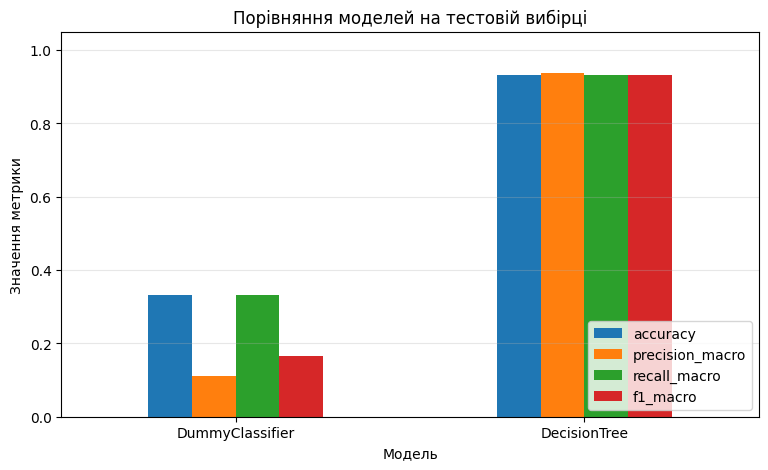

In [118]:
test_metrics = (
 metrics_df[
 metrics_df["dataset"] == "test"
 ]
 .set_index("model")
)
test_metrics[
 [
 "accuracy",
 "precision_macro",
 "recall_macro",
 "f1_macro"
 ]
].plot(
 kind="bar",
 figsize=(9, 5)
)
plt.title(
 "Порівняння моделей на тестовій вибірці"
)
plt.xlabel("Модель")
plt.ylabel("Значення метрики")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(
 loc="lower right"
)
plt.show()

Дайте відповіді:
1. Яка модель має вищу accuracy? - Дерево рішень
2. Яка модель має вищу F1-міру? - Дерево рішень
3. Наскільки дерево рішень перевищує DummyClassifier? - Майже в 3 рази
4. Чому недостатньо оцінювати модель лише за accuracy? - Бо ця метрика показує для якого відсотку модель правильно визначила клас. Але візьмемо за приклад DummyClassifier. Маємо навчальну вибірку де 75% клієнтів не хворі, інші хворі. Модель буде класифікувати всі об'єкти як не хворі. Тепер беремо тестову вибірку де до нас прийшло 100 клієнтів, 95 не хворі, інші 5 хворі. Модель каже що всі 100 не хворі і в результаті в нас 95% попадань. Наче гарна модель, пускаємо її в роботу. Але коли прийде наступний потік з 100 клієнтів, де 90 хворі, інші ні, то модель скаже всі здорові, і тепер буде тільки 10 попадань з 100. Однї метрики замало для адекватного оцінювання моделі.

In [119]:
train_test_comparison = metrics_df.pivot(
 index="model",
 columns="dataset",
 values=[
 "accuracy",
 "f1_macro"
 ]
)
display(
 train_test_comparison.round(3)
)


accuracy        f1_macro       
dataset             test  train     test  train
model                                          
DecisionTree       0.933  0.983    0.933  0.983
DummyClassifier    0.333  0.339    0.167  0.169

In [120]:
tree_train_accuracy = accuracy_score(
 y_train,
 tree_train_predictions
)
tree_test_accuracy = accuracy_score(
 y_test,
 tree_test_predictions
)
accuracy_gap = (
 tree_train_accuracy
 - tree_test_accuracy
)
print(
 "Accuracy на train:",
 round(tree_train_accuracy, 3)
)
print(
 "Accuracy на test:",
 round(tree_test_accuracy, 3)
)
print(
 "Різниця:",
 round(accuracy_gap, 3)
)

Accuracy на train: 0.983
Accuracy на test: 0.933
Різниця: 0.05


Завдання
На основі отриманих результатів визначте:
1. Чи недонавчений DummyClassifier? - Так
2. Чи є ознаки перенавчання дерева? - Є можливість, що дерево перенавчене, адже між точністю навчальної та тестової вирібрки є різниця в 5%, а результат на навчальній вибірці є занадто великим.
3. Чи має дерево прийнятну узагальнювальну здатність? - Залежить від конкретної задачі. Показники точності високі, різниця між ними 5%. Для деяких задач це прийнятна різниця, але ось наприклад для медицини не дуже.

## 5. Матриця помилок
Матриця помилок показує, які класи модель визначає
правильно,
а які плутає між собою.

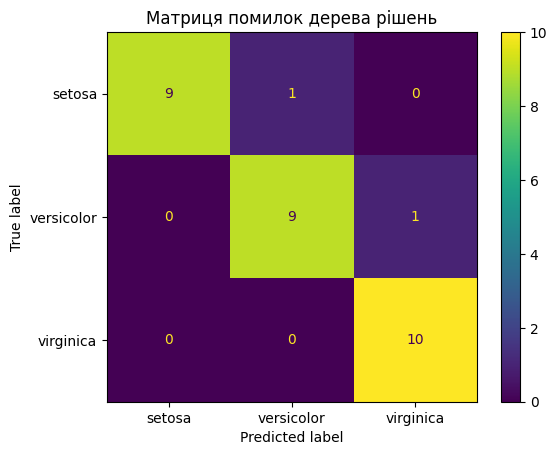

In [121]:
ConfusionMatrixDisplay.from_predictions(
 y_test,
 tree_test_predictions
)
plt.title(
 "Матриця помилок дерева рішень"
)
plt.show()

Завдання
Проаналізуйте матрицю:
1. Скільки об’єктів класифіковано правильно? - 28
2. Який клас розпізнається без помилок або майже без помилок? - virginica взагалі без помилок, інші з невеликою кількістю помилок (хоча щоб сказати точно великою чи невеликою кількістю помилок, бажано протестувати на більшій вибірці)
3. Які два класи модель плутає найчастіше? - setosa з versicolor і versicolor з verginica.
4. Чи узгоджується це з діаграмами ознак із попередньої роботи? - Не дуже, з тих діаграм можна було точно відділити setosa, а плутались versicolor i verginica.


In [122]:
test_results = X_test.copy()
test_results["actual"] = y_test.values
test_results["predicted"] = tree_test_predictions
test_results["correct"] = (
 test_results["actual"]
 == test_results["predicted"]
)


In [123]:
mistakes = test_results[
 ~test_results["correct"]
]
display(mistakes)

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,measurement_device_device_a,measurement_device_device_b,measurement_device_device_c,actual,predicted,correct
10,5.4,3.7,4.3,0.2,1,0,0,setosa,versicolor,False
77,6.7,3.0,5.0,1.7,0,1,0,versicolor,virginica,False


In [124]:
print(
 "Кількість помилкових прогнозів:",
 len(mistakes)
)

Кількість помилкових прогнозів: 2


Завдання для студента
Якщо помилки наявні, проаналізуйте:

 справжній клас;

 прогнозований клас;

 значення ознак;

 можливу причину помилки.

Якщо помилок немає, зазначте це у висновках і поясніть, чому на малому
тестовому наборі результат може залежати від випадкового розбиття.


In [125]:
display(
    X_test[y_test.values == "versicolor"].drop(
    columns=["measurement_device_device_a", "measurement_device_device_b", "measurement_device_device_c"]
    ))

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
75,6.6,3.0,4.4,1.4
66,5.6,3.0,4.5,1.5
57,4.9,2.4,3.3,1.0
84,5.4,3.0,4.5,1.5
56,6.3,3.3,4.7,1.6
51,6.4,3.2,4.5,1.5
63,6.1,2.9,4.7,1.4
69,5.6,2.5,3.9,1.1
58,6.6,2.9,4.6,1.3
77,6.7,3.0,5.0,1.7


In [126]:
display(
    X_test[y_test.values == "virginica"].drop(
    columns=["measurement_device_device_a", "measurement_device_device_b", "measurement_device_device_c"]
    ))

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
140,5.8,2.7,5.1,1.9
145,6.5,3.0,4.3,2.0
137,6.0,3.0,4.8,1.8
126,6.1,3.0,4.9,1.8
139,6.7,3.1,5.6,2.4
106,7.3,2.9,4.3,1.8
133,5.8,2.6,5.6,1.4
103,6.5,3.0,5.8,2.2
115,6.5,3.0,5.5,1.8
131,6.4,2.8,5.6,2.2


Можлива причина помилки - для правильних класів більш притаманні більші значення ознак, аніж подані в тесті, тому модель і помилилась. Такі значення більше підходять під виключення для тих класів.

## 6. Збереження навченої моделі
Модель зберігається разом із назвами ознак, щоб її можна було правильно використати в наступних роботах.


In [127]:
model_bundle = {
 "model": tree_model,
 "feature_columns": X.columns.tolist(),
 "target_classes": sorted(
 y.unique().tolist()
 )
}


In [128]:
joblib.dump(
 model_bundle,
 MODEL_PATH
)
print(
 "Модель збережено:",
 MODEL_PATH
)


Модель збережено: /content/drive/MyDrive/pattern-recognition-practice/models/iris_decision_tree.joblib


In [129]:
loaded_bundle = joblib.load(
 MODEL_PATH
)
loaded_model = loaded_bundle["model"]
print(
 "Ознаки моделі:",
 loaded_bundle["feature_columns"]
)
print(
 "Класи:",
 loaded_bundle["target_classes"]
)


Ознаки моделі: ['sepal_length_cm', 'sepal_width_cm', 'petal_length_cm', 'petal_width_cm', 'measurement_device_device_a', 'measurement_device_device_b', 'measurement_device_device_c']
Класи: ['setosa', 'versicolor', 'virginica']


In [130]:
one_object = X_test.iloc[[0]]
loaded_prediction = loaded_model.predict(
 one_object
)
print(
 "Справжній клас:",
 y_test.iloc[0]
)
print(
 "Прогноз моделі:",
 loaded_prediction[0]
)


Справжній клас: versicolor
Прогноз моделі: versicolor


In [131]:
metrics_df.to_csv(
 METRICS_PATH,
 index=False
)
print(
 "Таблицю метрик збережено:",
 METRICS_PATH
)


Таблицю метрик збережено: /content/drive/MyDrive/pattern-recognition-practice/reports/model_metrics.csv


In [132]:
assert X_train.isna().sum().sum() == 0, (
 "У X_train залишилися пропуски."
)
assert X_test.isna().sum().sum() == 0, (
 "У X_test залишилися пропуски."
)
assert len(tree_test_predictions) == len(y_test), (
 "Кількість прогнозів не відповідає "
 "кількості тестових об’єктів."
)
assert set(tree_test_predictions).issubset(
 set(y_train.unique())
), "Модель прогнозує невідомий клас."
assert MODEL_PATH.exists(), (
 "Файл моделі не збережено."
)
assert tree_test_accuracy > accuracy_score(
 y_test,
 dummy_test_predictions
), (
 "Дерево не перевищує базову модель. "
 "Перевірте підготовку даних."
)
print(
 "Усі основні перевірки виконано успішно."
)


Усі основні перевірки виконано успішно.


# Висновки
Під час виконання практичної роботи було побудовано перші
моделі машинного навчання для класифікації об’єктів набору Iris.
Як базовий орієнтир використано DummyClassifier, який завжди
прогнозував найпоширеніший клас. Його результати показали
рівень якості, який повинна перевищувати реальна модель.
Як основну модель побудовано дерево рішень із максимальною
глибиною 3. Модель було навчено на навчальній вибірці, після
чого
отримано прогнози для навчальних і тестових даних.
Якість моделей оцінено за accuracy, precision, recall і F1-
мірою.
Дерево рішень показало кращі результати порівняно з базовою
моделлю, що підтверджує наявність закономірностей між
ознаками квітки та її видом.
За допомогою матриці помилок було визначено, які класи
модель розпізнає правильно та які класи вона може плутати.
Порівняння результатів на навчальній і тестовій вибірках дало
змогу оцінити узагальнювальну здатність моделі.
Навчену модель і перелік використаних ознак збережено у
форматі joblib для подальшого використання.

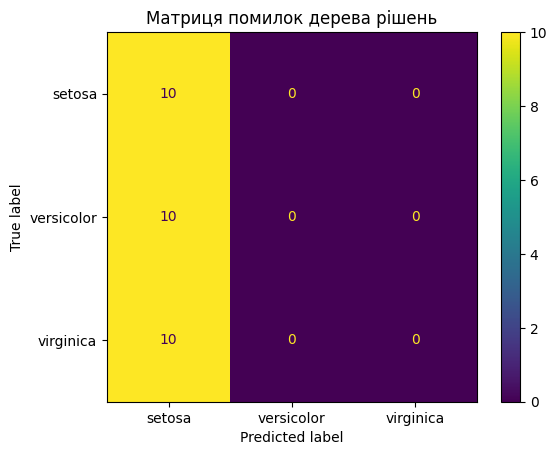

In [133]:
ConfusionMatrixDisplay.from_predictions(
 y_test,
 dummy_test_predictions
)
plt.title(
 "Матриця помилок дерева рішень"
)
plt.show()

- accuracy DummyClassifier на test - 0.333
- accuracy дерева на train - 0.983
- accuracy дерева на test - 0.933
- F1-міру дерева - 0.983 для трейн і 0.933 для тест
- різницю між train і test - для моделі дерева рішень = 0.05 (5%), для DummyClassifier = 0.006 (0.6%)
- кількість помилкових прогнозів - Для дерева рішень = 2шт., для DummyClassifier = 20шт.
- класи, які модель плутає найчастіше - setosa з versicolor і versicolor з verginica
- висновок щодо недонавчання або перенавчання - dummy_model точно недонавчена модель, tree_model можливо трохи перенавчена.

## Додаткове завдання
Побудувати дерево рішень без обмеження глибини

In [134]:
deep_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

In [135]:
deep_tree.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(random_state=42)

In [136]:
deep_tree_train_predict = deep_tree.predict(X_train)
deep_tree_test_predict = deep_tree.predict(X_test)

In [137]:
print(
    "Train accurancy: ",
    accuracy_score(
        y_train,
        deep_tree_train_predict
    )
)

print(
    "Test accurancy: ",
    accuracy_score(
        y_test,
        deep_tree_test_predict
    )
)

Train accurancy:  1.0
Test accurancy:  0.9


Дайте відповіді:
1. Чи досягло необмежене дерево accuracy 1,0 на train? - Так
2. Чи покращилася якість на test? - Ні
3. Чи збільшився розрив між train і test? - Так
4. Чи можна вважати це ознакою перенавчання? - Це абсолютно точно перенавчання. На навчальних даних модель працює ідеально (точність 100%), а на тестових значно гірше (розрив 10%).